# Comparison of Results: Config A vs Config B

## 1. Imports

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Import Results 

In [4]:
comparison_df = pd.read_excel(
    "ddqn_ppo_results.xlsx",
    sheet_name="Overall Comparison"
)

comparison_df

,Algorithm,Mean Return,Survival Rate,Training Episodes,buffer_size,target_update_freq
0,Random,0.561722,0.65454,0,-,-
1,Double DQN,0.600900,0.68300,50000,100000,50
2,PPO,0.644000,0.67000,50000,N/A (on-policy),N/A (on-policy)


In [3]:
config_a_df = pd.read_excel(
    "config_a_results.xlsx",
    sheet_name="Overall Comparison"
)

config_a_df

,Algorithm,Mean Return,Survival Rate,Mean Length,Runtime (s),Convergence Type,Convergence Count,Value Updates
0,Random,0.590075,0.6940,10.32400,NaN,NaN,NaN,NaN
1,Policy Iteration,0.786502,0.8252,9.84536,6.025020,Policy improvement rounds,4.0,736.0
2,Value Iteration,0.786502,0.8252,9.84536,29.489921,Bellman updates,81.0,81.0


## 3. Comparison 

In [6]:
config_a_df["Configuration"] = "Config A"
comparison_df["Configuration"] = "Config B"

comparison_df["Mean Length"] = None
comparison_df["Runtime (s)"] = None

combined_df = pd.concat(
    [
        config_a_df[
            ["Configuration", "Algorithm", "Mean Return",
             "Survival Rate", "Mean Length"]
        ],
        comparison_df[
            ["Configuration", "Algorithm", "Mean Return",
             "Survival Rate", "Mean Length"]
        ]
    ],
    ignore_index=True
)

display(combined_df)

C:\Users\Oliver\AppData\Local\Temp\ipykernel_23420\1238450222.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(


,Configuration,Algorithm,Mean Return,Survival Rate,Mean Length
0,Config A,Random,0.590075,0.69400,10.32400
1,Config A,Policy Iteration,0.786502,0.82520,9.84536
2,Config A,Value Iteration,0.786502,0.82520,9.84536
3,Config B,Random,0.561722,0.65454,NaN
4,Config B,Double DQN,0.600900,0.68300,NaN
5,Config B,PPO,0.644000,0.67000,NaN


In [14]:
combined_df["Label"] = (
    combined_df["Algorithm"]
    + " ("
    + combined_df["Configuration"]
    + ")"
)

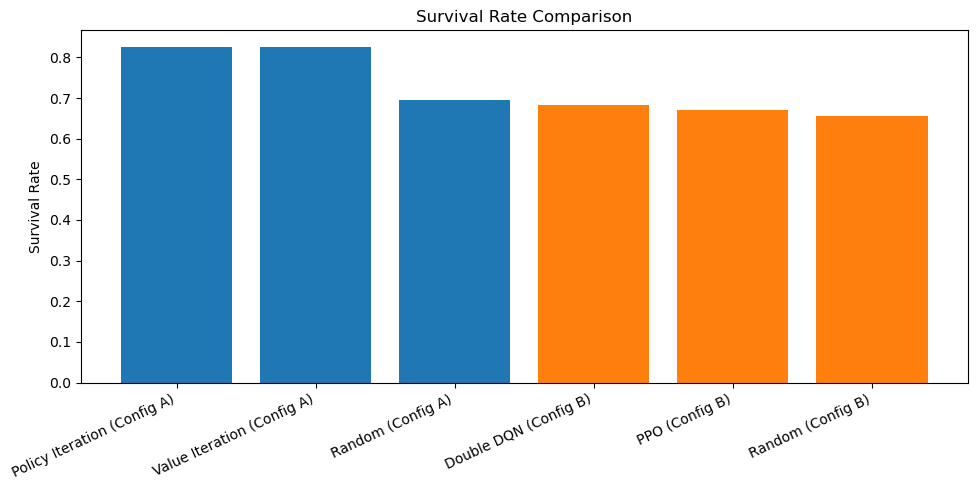

In [19]:
combined_df = combined_df.sort_values(
    "Survival Rate",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Survival Rate"],
    color=colors
)

plt.ylabel("Survival Rate")
plt.title("Survival Rate Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

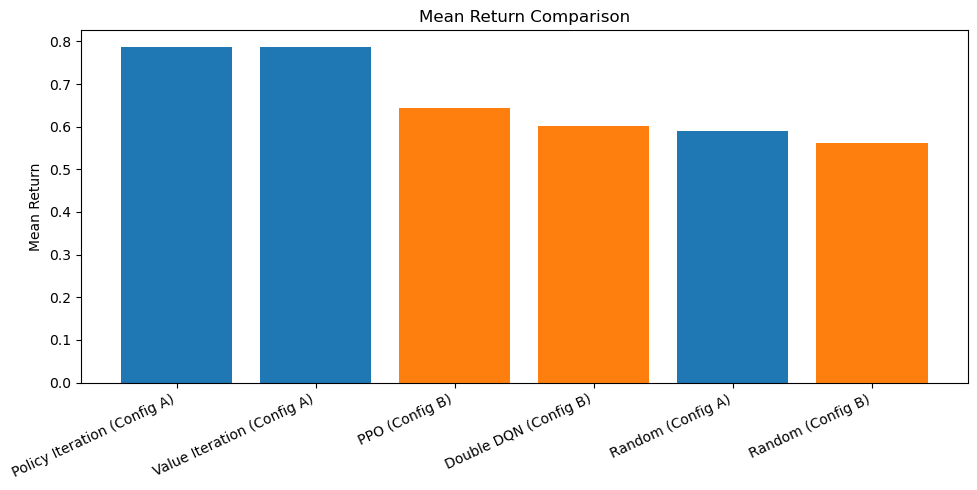

In [22]:
combined_df = combined_df.sort_values(
    "Mean Return",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Mean Return"],
    color=colors
)

plt.ylabel("Mean Return")
plt.title("Mean Return Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

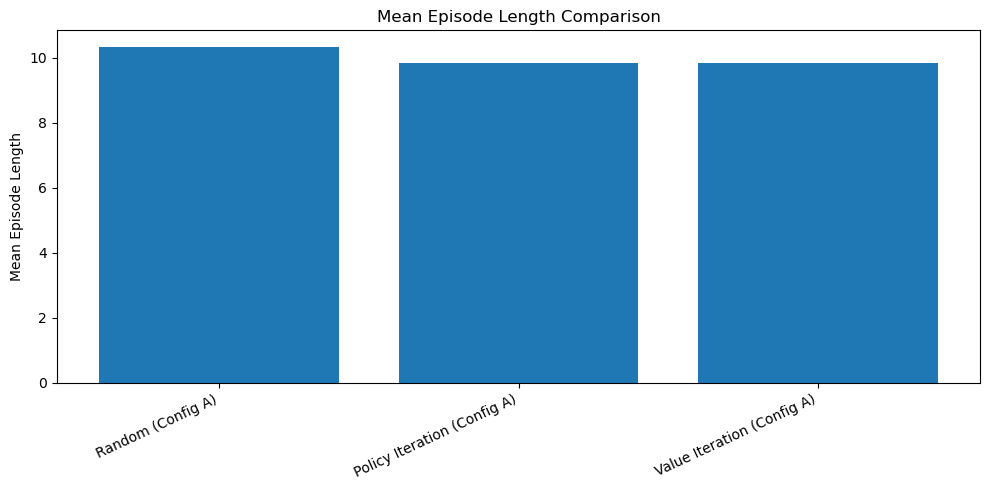

In [23]:
combined_df = combined_df.sort_values(
    "Mean Length",
    ascending=False
)

colors = combined_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    combined_df["Label"],
    combined_df["Mean Length"],
    color=colors
)

plt.ylabel("Mean Episode Length")
plt.title("Mean Episode Length Comparison")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

In [28]:
random_a = combined_df[
    (combined_df["Configuration"] == "Config A") &
    (combined_df["Algorithm"] == "Random")
].iloc[0]

random_b = combined_df[
    (combined_df["Configuration"] == "Config B") &
    (combined_df["Algorithm"] == "Random")
].iloc[0]

combined_df["Return Improvement (%)"] = combined_df.apply(
    lambda row:
    ((row["Mean Return"] - random_a["Mean Return"]) / random_a["Mean Return"] * 100)
    if row["Configuration"] == "Config A"
    else
    ((row["Mean Return"] - random_b["Mean Return"]) / random_b["Mean Return"] * 100),
    axis=1
)

combined_df["Survival Improvement (%)"] = combined_df.apply(
    lambda row:
    ((row["Survival Rate"] - random_a["Survival Rate"]) / random_a["Survival Rate"] * 100)
    if row["Configuration"] == "Config A"
    else
    ((row["Survival Rate"] - random_b["Survival Rate"]) / random_b["Survival Rate"] * 100),
    axis=1
)

combined_df["Combined Improvement (%)"] = (
    combined_df["Return Improvement (%)"]
    + combined_df["Survival Improvement (%)"]
)

plot_df = combined_df[
    combined_df["Algorithm"] != "Random"
].copy()

plot_df["Label"] = (
    plot_df["Algorithm"] + " (" + plot_df["Configuration"] + ")"
)

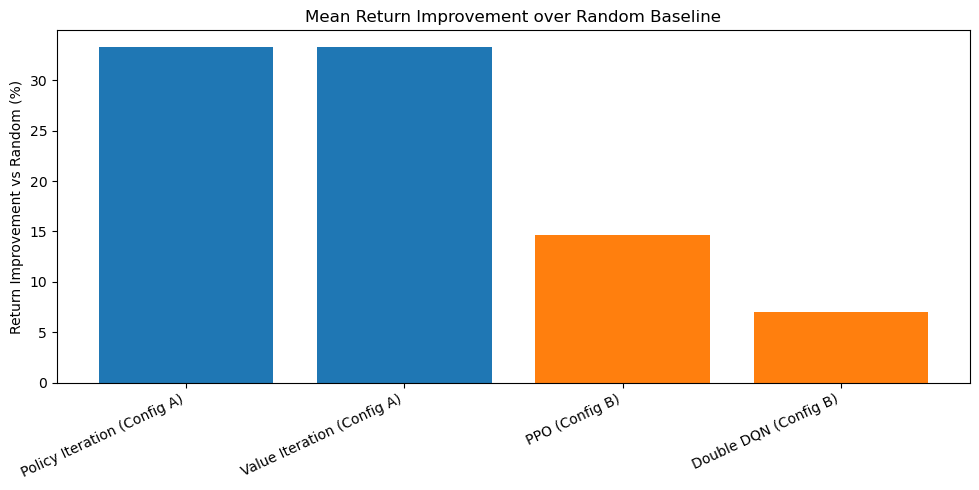

In [29]:
plot_df = plot_df.sort_values(
    "Return Improvement (%)",
    ascending=False
)

colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Return Improvement (%)"],
    color=colors
)

plt.ylabel("Return Improvement vs Random (%)")
plt.title("Mean Return Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

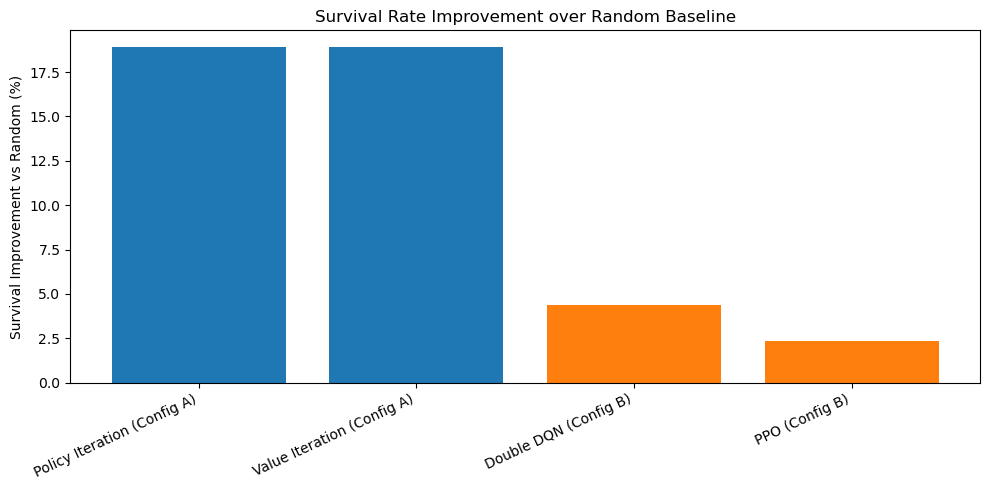

In [30]:
plot_df = plot_df.sort_values(
    "Survival Improvement (%)",
    ascending=False
)

colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Survival Improvement (%)"],
    color=colors
)

plt.ylabel("Survival Improvement vs Random (%)")
plt.title("Survival Rate Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.tight_layout()

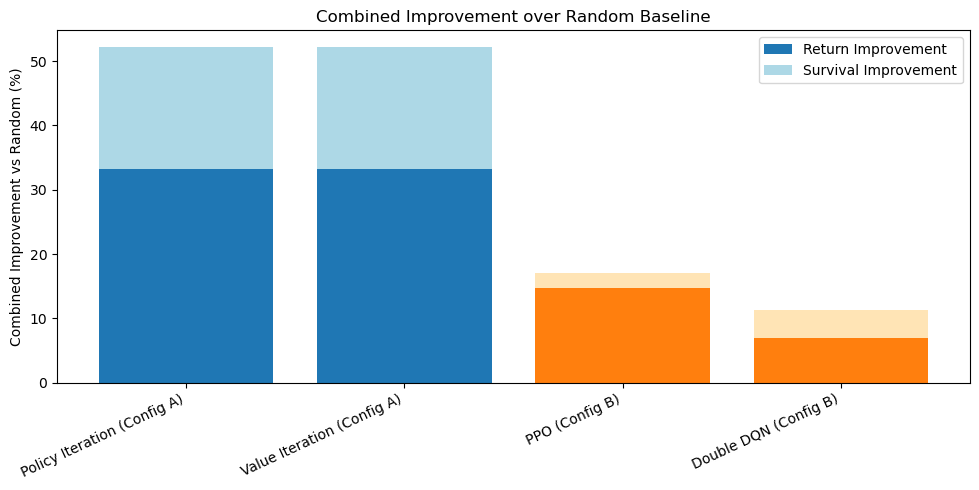

In [33]:
plot_df = plot_df.sort_values(
    "Combined Improvement (%)",
    ascending=False
)

return_colors = plot_df["Configuration"].map({
    "Config A": "tab:blue",
    "Config B": "tab:orange"
})

survival_colors = plot_df["Configuration"].map({
    "Config A": "lightblue",
    "Config B": "moccasin"
})

plt.figure(figsize=(10,5))

plt.bar(
    plot_df["Label"],
    plot_df["Return Improvement (%)"],
    color=return_colors,
    label="Return Improvement"
)

plt.bar(
    plot_df["Label"],
    plot_df["Survival Improvement (%)"],
    bottom=plot_df["Return Improvement (%)"],
    color=survival_colors,
    label="Survival Improvement"
)

plt.ylabel("Combined Improvement vs Random (%)")
plt.title("Combined Improvement over Random Baseline")
plt.xticks(rotation=25, ha="right")

plt.legend()

plt.tight_layout()